# README
1. AUSPEX is a BBN instrumnet control package. 
2. We are using SRS SR865 lockin + RenSci piezo stage. Both connected via ethernet with static IP addresses
3. AUSPEX has a number of 'import visa' scattered across the source code; needs to be updated to 'import pyvisa as visa'. Best to push these changes or fork the repo and have a local copy.
4. distance unit is in millimeter.

In [ ]:
%load_ext autoreload
%autoreload 2
from auspex.instruments import SR865
from rensci import RenSciDriver
import numpy as np
import matplotlib.pyplot as plt
import time

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
PIEZO_HOST = "172.31.255.99"
PIEZO_PORT = 6002

lockin = SR865()
lockin.connect('TCPIP0::172.31.255.252')

print(f"Connected to {lockin.name} \n\n X= {lockin.x}, Y = {lockin.y}")

xyz = RenSciDriver(PIEZO_HOST, PIEZO_PORT)
xyz.connect()

Connected to SR865 Lockin Amplifier 

 X= -5.8731647101e-08, Y = 3.4784352465e-07
Connected to 172.31.255.99:6002


In [7]:
xyz.goPosition(1, -4.4)
xyz.wait_closed_loop_done()
xyz.goPosition(2, -1.15)
xyz.wait_closed_loop_done()
xyz.goPosition(3, -3.23)
xyz.wait_closed_loop_done()

r=[]
# for i in range(100):
#     xyz.goStepsForward(1, steps=10)
#     r.append(lockin.r)

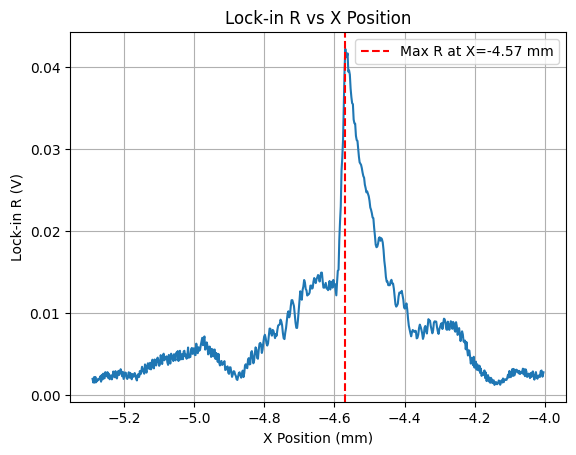

In [18]:
r = np.array(r)
x = np.array(x)
np.argmax(r)

plt.plot(x, r)
plt.xlabel("X Position (mm)")
plt.ylabel("Lock-in R (V)")
plt.title("Lock-in R vs X Position")
plt.axvline(x[np.argmax(r)], color='r', linestyle='--', label=f'Max R at X={x[np.argmax(r)]:.2f} mm')
plt.grid()
plt.legend()

In [19]:
xyz.goPosition(1, x[np.argmax(r)]  )

{'id': '24921', 'jsonrpc': '2.0', 'result': True}

In [28]:
xyz.goPosition(2, -1.15 )
nsteps = 2000
stepsize = 10
y = []
r= []
xyz.goStepsReverse(2, int(nsteps/2))
for i in range(nsteps):
    r.append(lockin.r)
    y.append(xyz.getPosition(2))
    xyz.goStepsForward(2, stepsize)

In [16]:
r[263]

np.float64(0.042213559151)

/var/folders/62/mcqwstd50y96l1tfpcvcwz6w0000gn/T/ipykernel_32257/2211636307.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


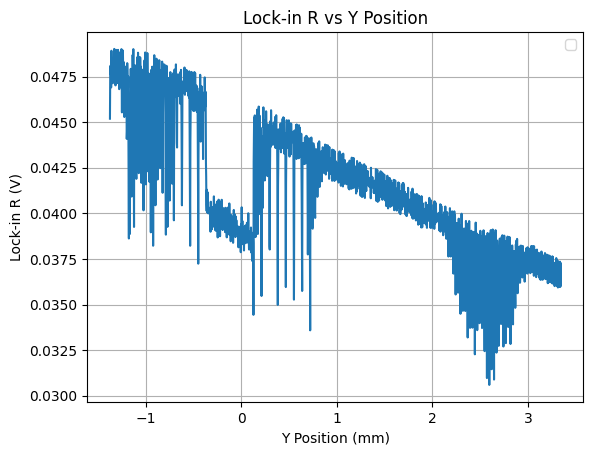

In [29]:
r = np.array(r)
y = np.array(y)
# np.argmax(r)

plt.plot(y, r)
plt.xlabel("Y Position (mm)")
plt.ylabel("Lock-in R (V)")
plt.title("Lock-in R vs Y Position")
# plt.axvline(y[np.argmax(r)], color='r', linestyle='--', label=f'Max R at Y={y   [np.argmax(r)]:.2f} mm')
plt.grid()
plt.legend()

In [27]:
np.mean(np.diff(y))*1e3

np.float64(4.828772024525778)

In [4]:
def refocus(channel=1, nsteps=200, stepsize=10, lockin_time_constant=0.03):
    x=[]
    r=[]
    xyz.goStepsReverse(channel, int(nsteps/2)*stepsize)
    for i in range(nsteps):
        time.sleep(lockin_time_constant * 5)  # Wait for lock-in to stabilize
        r.append(lockin.r)
        x.append(xyz.getPosition(channel))
        xyz.goStepsForward(channel, stepsize)
    r = np.array(r)
    x = np.array(x)
    xyz.wait_open_loop_done()
    return x[np.argmax(r)], x,r



    
def getStepDistance(channel=2, stepSize=10, nsteps=10):
    step = []
    distance = []

    # Record the starting position
    startPosition = xyz.getPosition(channel)

    for i in range(nsteps):
        xyz.goStepsForward(channel, stepSize)
        step.append((i + 1) * stepSize)
        distance.append(xyz.getPosition(channel) - startPosition)

    # Linear fit: distance = slope * step + intercept
    coeffs = np.polyfit(step, distance, 1)
    slope = coeffs[0]  # microns per step unit

    # Distance per single step (stepSize=1)
    distancePerStep = slope  # mm/step
    xyz.goPosition(channel, startPosition)  # Return to original position
    return distancePerStep


# xyz.goPosition(1, refocus(channel=1)[0])


In [ ]:
#test getStepDistance
xyz.goPosition(2, -1.15 )
distancePerStep = getStepDistance(channel=2, stepSize=10, nsteps=10)
print(f"Distance per step unit: {distancePerStep:.4f} mm/step")


Distance per step unit: 0.2533 microns/step


In [35]:
xyz.goPosition(2, -1.15)

{'id': '463', 'jsonrpc': '2.0', 'result': True}

In [39]:
print({k: v for k, v in vars(type(lockin)).items() if 'filter' in k.lower()})

{'FILTER_SLOPE_VALUES': [6, 12, 18, 24], 'FILTER_SLOPE_MAP': {6: '0', 12: '1', 18: '2', 24: '3'}, 'filter_slope': <property object at 0x11e64f3d0>, 'get_filter_slope': <function add_command_SCPI.<locals>.fget at 0x11e69f7e0>, 'set_filter_slope': <function add_command_SCPI.<locals>.fset at 0x11e69f880>}


In [9]:
xyz.goPosition(2, -1.15)
xyz.goPosition(1, 4.592440)
xyz.goPosition(3, -3.23)


True

>> Initializing position...
   Starting position: X=4.5924, Y=-1.1500, Z=-3.2300 mm

>> Calibrating step distance...
   Resolution (mm/step): 0.0013
   Total steps: 62


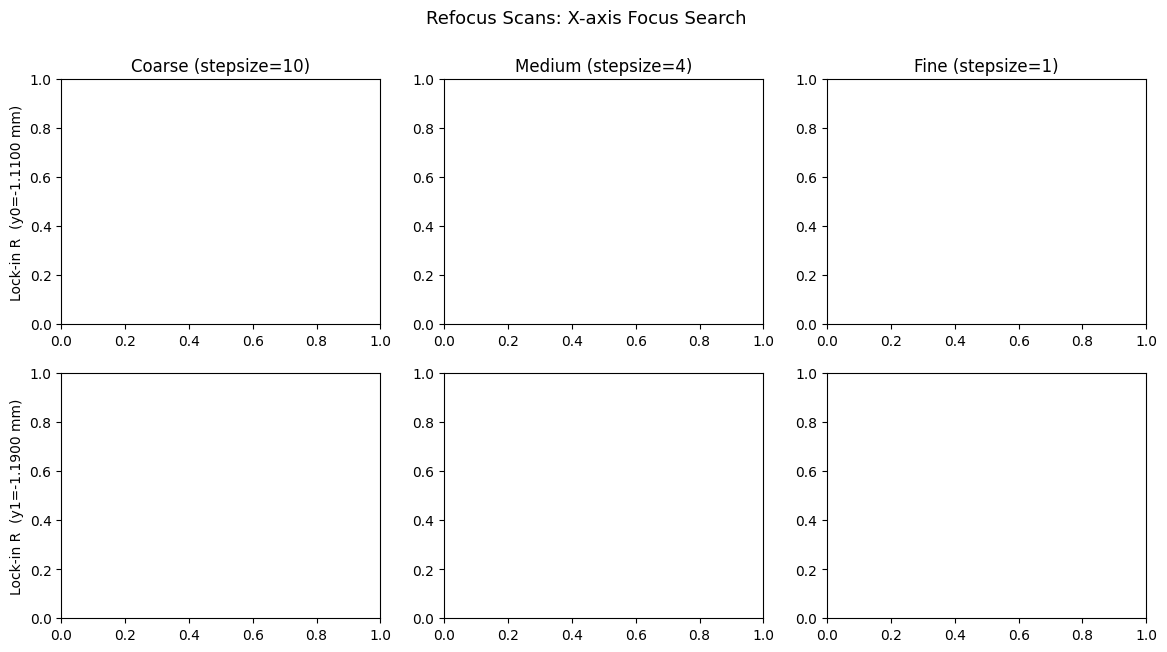


>> Finding focus at y0=-1.1100 mm...
   Coarse refocus (stepsize=10)...
   Medium refocus (stepsize=4)...
   Fine refocus (stepsize=1)...
   x0 = 4.5921 mm

>> Finding focus at y1=-1.1900 mm...
   Coarse refocus (stepsize=10)...
   Medium refocus (stepsize=4)...
   Fine refocus (stepsize=1)...
   x1 = 4.5914 mm

>> Defocus slope computed:
   Focus X at y0=-1.110: 4.5921 mm
   Focus X at y1=-1.190: 4.5914 mm
   Defocus slope: 0.0086 mm/mm

========== SCAN PARAMETERS ==========
  Lock-in frequency  : 150000.00 Hz
  Time constant      : 1.0 ms
  Sensitivity        : 0.5 mV
  Filter slope       : 18 dB/oct
  Start position     : X=4.5924, Y=-1.1500, Z=-3.2300 mm
  Scan axis          : Y  (-1.1100 → -1.1900 mm)
  Scan size          : 0.080 mm
  Step size          : 5 | Step distance: 0.0003 mm | Total steps: 62
  Resolution         : 0.0013 mm/step



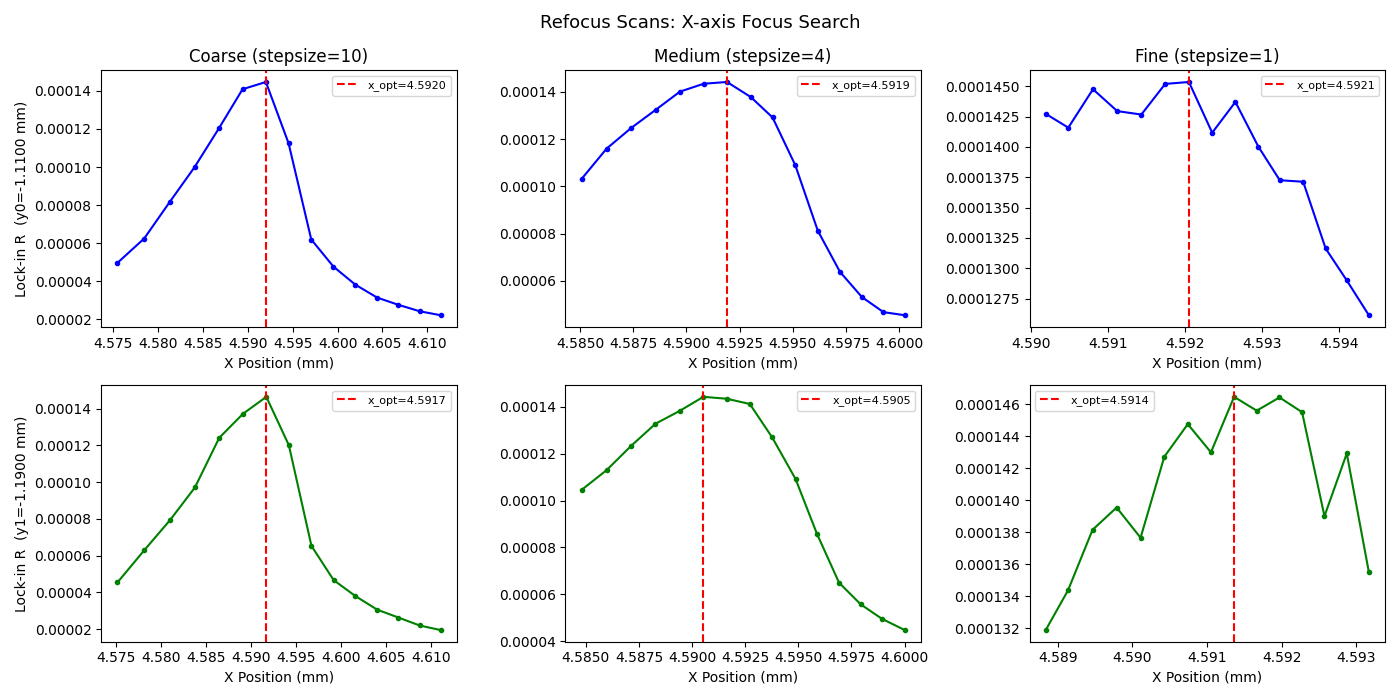

In [ ]:
#  LZ - 06/04/2026
# Refocus line estimate and test line scan (claude version)

#lock-in setting
lockin.amplitude = 0.15
lockin.frequency = 150*1e3
lockin.time_constant = 1e-3
lockin.sensitivity = 500*1e-6
lockin.phase = 0
lockin.filter_slope = 18

# Parameters (defined first)
stepsize = 5          # scanning resolution; smaller = higher res, slower
scanYSize = 0.08      # total scan size in Y (mm)
nrefocus = 10         # number of inline refocus points during line scan

# Initialize position
print(">> Initializing position...")
xyz.goPosition(2, -1.15)
xyz.goPosition(1, 4.592440)
xyz.goPosition(3, -3.23)
currentXPosition = xyz.getPosition(1)
currentYPosition = xyz.getPosition(2)
currentZPosition = xyz.getPosition(3)
print(f"   Starting position: X={currentXPosition:.4f}, Y={currentYPosition:.4f}, Z={currentZPosition:.4f} mm")

# Calibrate step distance and compute number of steps
print("\n>> Calibrating step distance...")
yOneStepDistance = getStepDistance(channel=2, stepSize=stepsize, nsteps=10)
nsteps = int(round(scanYSize / (yOneStepDistance*stepsize)))
print(f"   Resolution (mm/step): {yOneStepDistance * stepsize:.4f}")
print(f"   Total steps: {nsteps}")

# Scan range endpoints
y0 = currentYPosition + scanYSize / 2
y1 = currentYPosition - scanYSize / 2

# Setup refocus figure
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('Refocus Scans: X-axis Focus Search', fontsize=13)
for col, title in enumerate(['Coarse (stepsize=10)', 'Medium (stepsize=4)', 'Fine (stepsize=1)']):
    axes[0, col].set_title(title)
axes[0, 0].set_ylabel(f'Lock-in R  (y0={y0:.4f} mm)')
axes[1, 0].set_ylabel(f'Lock-in R  (y1={y1:.4f} mm)')
display(fig)

# ── Find focus at y0 ──────────────────────────────────────
print(f"\n>> Finding focus at y0={y0:.4f} mm...")
xyz.goPosition(2, y0)

for col, ss in enumerate([10, 4, 1]):
    label = ['Coarse', 'Medium', 'Fine'][col]
    print(f"   {label} refocus (stepsize={ss})...")
    x_opt, x_scan, r_scan = refocus(channel=1, nsteps=15, stepsize=ss,
                                     lockin_time_constant=lockin.time_constant)
    xyz.goPosition(1, x_opt)
    x0 = x_opt

    ax = axes[0, col]
    ax.plot(x_scan, r_scan, 'b.-')
    ax.axvline(x_opt, color='r', linestyle='--', label=f'x_opt={x_opt:.4f}')
    ax.legend(fontsize=8)
    ax.set_xlabel('X Position (mm)')
    fig.canvas.draw()
    fig.canvas.flush_events()

print(f"   x0 = {x0:.4f} mm")

# ── Find focus at y1 ──────────────────────────────────────
print(f"\n>> Finding focus at y1={y1:.4f} mm...")
xyz.goPosition(2, y1)

for col, ss in enumerate([10, 4, 1]):
    label = ['Coarse', 'Medium', 'Fine'][col]
    print(f"   {label} refocus (stepsize={ss})...")
    x_opt, x_scan, r_scan = refocus(channel=1, nsteps=15, stepsize=ss,
                                     lockin_time_constant=lockin.time_constant)
    xyz.goPosition(1, x_opt)
    x1 = x_opt

    ax = axes[1, col]
    ax.plot(x_scan, r_scan, 'g.-')
    ax.axvline(x_opt, color='r', linestyle='--', label=f'x_opt={x_opt:.4f}')
    ax.legend(fontsize=8)
    ax.set_xlabel('X Position (mm)')
    fig.canvas.draw()
    fig.canvas.flush_events()

print(f"   x1 = {x1:.4f} mm")
fig.tight_layout()

# Compute initial defocus slope from two endpoints
defocusSlope = (x1 - x0) / (y1 - y0)
print(f"\n>> Defocus slope computed:")
print(f"   Focus X at y0={y0:.3f}: {x0:.4f} mm")
print(f"   Focus X at y1={y1:.3f}: {x1:.4f} mm")
print(f"   Defocus slope: {defocusSlope:.4f} mm/mm")

# ── Scan summary ──────────────────────────────────────────
print("\n========== SCAN PARAMETERS ==========")
print(f"  Lock-in frequency  : {lockin.frequency:.2f} Hz")
print(f"  Time constant      : {lockin.time_constant*1e3:.1f} ms")
print(f"  Sensitivity        : {lockin.sensitivity*1e3:.1f} mV")
print(f"  Filter slope       : {lockin.filter_slope} dB/oct")
print(f"  Start position     : X={currentXPosition:.4f}, Y={currentYPosition:.4f}, Z={currentZPosition:.4f} mm")
print(f"  Scan axis          : Y  ({y0:.4f} → {y1:.4f} mm)")
print(f"  Scan size          : {scanYSize:.3f} mm")
print(f"  Step size          : {stepsize} | Step distance: {yOneStepDistance:.4f} mm | Total steps: {nsteps}")
print(f"  Resolution         : {yOneStepDistance * stepsize:.4f} mm/step")
print(f"  Inline refocus pts : {nrefocus}")
print("=====================================\n")

In [ ]:
#Lingwen - 06/04/2026
# ── Line scan ─────────────────────────────────────────────

# Return to start of scan
print("\n>> Returning to scan start...")
xyz.goPosition(2, y0)
xyz.goPosition(1, x0)

# Recalibrate step distance
print("\n>> Calibrating step distance...")
yOneStepDistance = getStepDistance(channel=2, stepSize=stepsize, nsteps=10)
nsteps = int(round(scanYSize / yOneStepDistance))

# Inline refocus: trigger at centre of each segment
refocusStepIndices = [int(round((k + 0.5) * nsteps / nrefocus)) for k in range(nrefocus)]
print(f"   Inline refocus at steps: {refocusStepIndices}")

# Seed the fit with the two pre-scan endpoints
coeffs = np.polyfit([y0, y1], [x0, x1], 1)
xFocusPositions = [x0, x1]
yFocusPositions = [y0, y1]

# Line scan with live focus correction
print(f"\n>> Starting line scan ({nsteps} steps)...")
yPosition = []
r = []
last_reported = -1

for i in range(nsteps):
    xyz.goStepsReverse(2, stepsize)
    currentY = xyz.getPosition(2)
    yPosition.append(currentY)

    # Inline refocus at scheduled steps
    if i in refocusStepIndices:
        refocus_num = refocusStepIndices.index(i) + 1
        print(f"\n   >> Inline refocus {refocus_num}/{nrefocus} at step {i}, Y={currentY:.4f} mm...")
        xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=10,
                                   lockin_time_constant=lockin.time_constant)[0])
        xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=4,
                                   lockin_time_constant=lockin.time_constant)[0])
        x_opt, _, _ = refocus(channel=1, nsteps=15, stepsize=1,
                               lockin_time_constant=lockin.time_constant)
        xyz.goPosition(1, x_opt)
        xFocusPositions.append(x_opt)
        yFocusPositions.append(currentY)
        # Update fit with all points so far
        coeffs = np.polyfit(yFocusPositions, xFocusPositions, 1)
        print(f"      x_focus={x_opt:.4f} mm | updated slope={coeffs[0]:.4f} mm/mm")

    xyz.goPosition(1, np.polyval(coeffs, currentY))
    time.sleep(lockin.time_constant * 5)
    r.append(lockin.r)

    pct = int((i + 1) / nsteps * 100)
    milestone = (pct // 5) * 5
    if milestone > last_reported:
        print(f"   Scan progress: {milestone}%  (step {i+1}/{nsteps}, Y={currentY:.4f} mm)")
        last_reported = milestone

print(">> Scan complete.")

# Plot line scan
plt.figure()
plt.plot(yPosition, r)
plt.xlabel('Y Position (mm)')
plt.ylabel('Lock-in Signal (V)')
plt.title('Lock-in Signal vs Y Position')
plt.show()


In [ ]:
#  LZ - 06/02/2026
#  before claude edits
#  Refocus line estimate and test line scan

#lock-in setting
lockin.frequency = 1.7777e3
lockin.time_constant = 3e-3
lockin.sensitivity = 10*1e-3
lockin.phase = 0
lockin.filter_slope = 6

# Parameters (defined first)
stepsize = 2          # scanning resolution; smaller = higher res, slower
scanYSize = 0.05       # in mm

# Initialize position
xyz.goPosition(2, -1.15)
xyz.goPosition(1, 4.4)
xyz.goPosition(3, -3.23)
currentXPosition = xyz.getPosition(1)
currentYPosition = xyz.getPosition(2)
currentZPosition = xyz.getPosition(3)

# Calibrate step distance and compute number of steps
yOneStepDistance = getStepDistance(channel=2, stepSize=stepsize, nsteps=10)
nsteps = int(round(scanYSize / (yOneStepDistance * stepsize)))
print(f"Resolution (mm/step): {yOneStepDistance * stepsize:.4f}")
print(f"Total steps: {nsteps}")

# Scan range endpoints
y0 = currentYPosition + scanYSize / 2
y1 = currentYPosition - scanYSize / 2

# Find focus at y0
xyz.goPosition(2, y0)
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=10)[0])
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=4)[0])
x0 = refocus(channel=1, nsteps=15, stepsize=1)[0]
xyz.goPosition(1, x0)

# Find focus at y1
xyz.goPosition(2, y1)
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=10)[0])
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=4)[0])
x1 = refocus(channel=1, nsteps=15, stepsize=1)[0]
xyz.goPosition(1, x1)

# Compute defocus slope
defocusSlope = (x1 - x0) / (y1 - y0)
print(f"Focus X at y0={y0:.3f}: {x0:.4f} mm")
print(f"Focus X at y1={y1:.3f}: {x1:.4f} mm")
print(f"Defocus slope: {defocusSlope:.4f} mm/mm")

# Return to start of scan
xyz.goPosition(2, y0)
xyz.goPosition(1, x0)

# Line scan with live focus correction
yPosition = []
r = []

for i in range(nsteps):
    xyz.goStepsReverse(2, stepsize)
    currentY = xyz.getPosition(2)
    yPosition.append(currentY)
    xyz.goPosition(1, x0 + defocusSlope * (currentY - y0))
    r.append(lockin.r)

# Plot
plt.plot(yPosition, r)
plt.xlabel('Y Position (mm)')
plt.ylabel('Lock-in Signal (V)')
plt.title('Lock-in Signal vs Y Position')
plt.show()

Resolution (mm/step): 0.0012
Total steps: 1663
Focus X at y0=-0.900: 4.4160 mm
Focus X at y1=-1.400: 4.4212 mm
Defocus slope: -0.0106 mm/mm


KeyboardInterrupt: 

In [ ]:

x0, x, r = refocus(1)

NameError: name 'refocus' is not defined

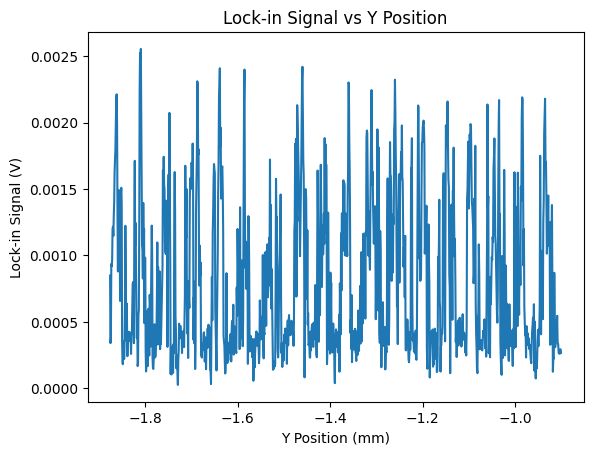

In [53]:
# Plot
plt.plot(yPosition, r)
plt.xlabel('Y Position (mm)')
plt.ylabel('Lock-in Signal (V)')
plt.title('Lock-in Signal vs Y Position')
plt.show()

In [68]:
xyz.goPosition(1, x0)

{'id': '228266', 'jsonrpc': '2.0', 'result': True}

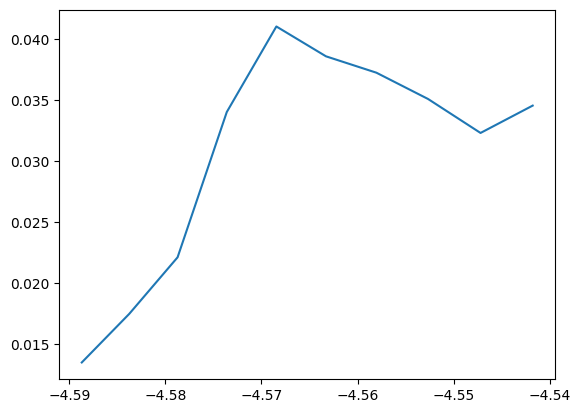

In [72]:
plt.plot(x,r)

In [57]:
xyz.goPosition(1, x0)

{'id': '226381', 'jsonrpc': '2.0', 'result': True}

In [41]:
np.mean(np.diff(refocus(channel=1)[1]))

np.float64(-0.009523392657737209)

In [74]:
xyz.goPosition(2, -1.15 )
nsteps = 200
stepsize = 20
y = []
r= []
x0=[]
xyz.goStepsReverse(2, int(nsteps/2)*stepsize)
for i in range(nsteps):
    r.append(lockin.r)
    y.append(xyz.getPosition(2))
    xyz.goStepsForward(2, stepsize)
    
    x0.append( refocus(channel=1)[0] )
    xyz.goPosition(1, x0[-1])



KeyboardInterrupt: 

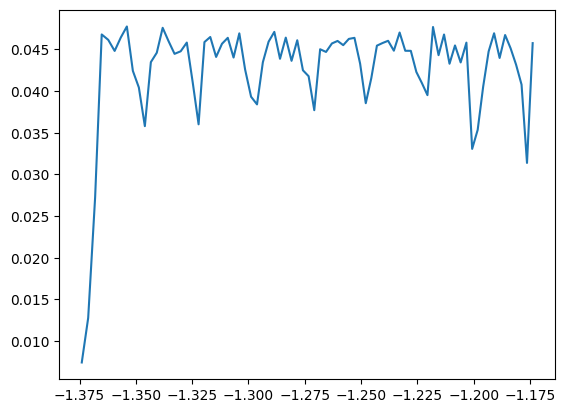

In [43]:
plt.plot(y, r)

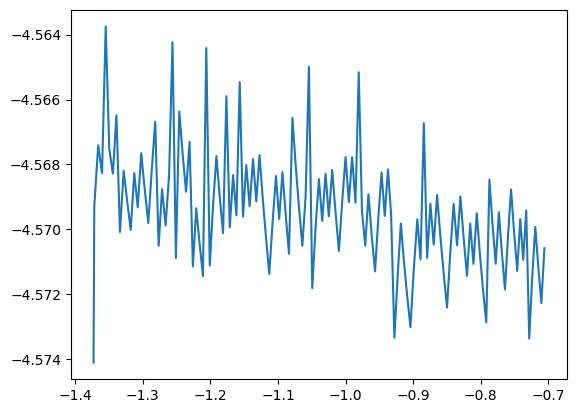

In [80]:
plt.plot(y[:-1],x0)

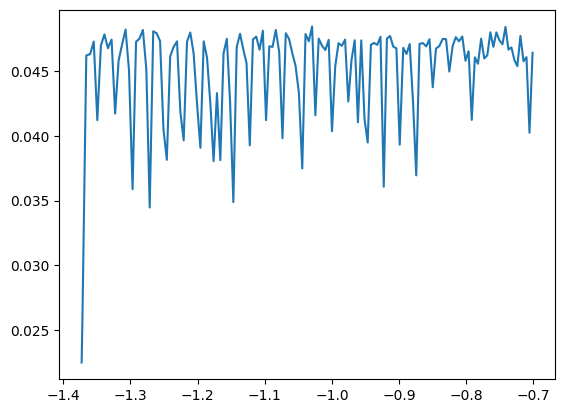

In [81]:
plt.plot(y, r)

In [83]:
np.mean(np.diff(y))*1e3

np.float64(4.86577745693015)

# June 3

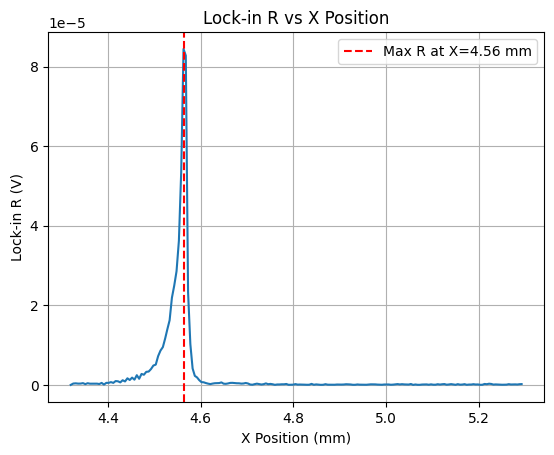

In [ ]:
# focus is around 4.563198
xyz.goStepsReverse(1, steps=20*100)
r=[]
x = []
for i in range(200):
    xyz.goStepsForward(1, steps=20)
    r.append(lockin.r)
    x.append(xyz.getPosition(1))

r = np.array(r) 
x = np.array(x)
np.argmax(r)

plt.plot(x, r)
plt.xlabel("X Position (mm)")
plt.ylabel("Lock-in R (V)")
plt.title("Lock-in R vs X Position")
plt.axvline(x[np.argmax(r)], color='r', linestyle='--', label=f'Max R at X={x[np.argmax(r)]:.5f} mm')
plt.grid()
plt.legend()

<>:4: SyntaxWarning: invalid escape sequence '\O'
<>:4: SyntaxWarning: invalid escape sequence '\O'
/var/folders/62/mcqwstd50y96l1tfpcvcwz6w0000gn/T/ipykernel_32257/3349651107.py:4: SyntaxWarning: invalid escape sequence '\O'
  plt.title("Lock-in R vs X Position\n 10M$\Omega$ terminated. 150kHz modulation, tc=1ms, 6dB/oct, A=150mV ")


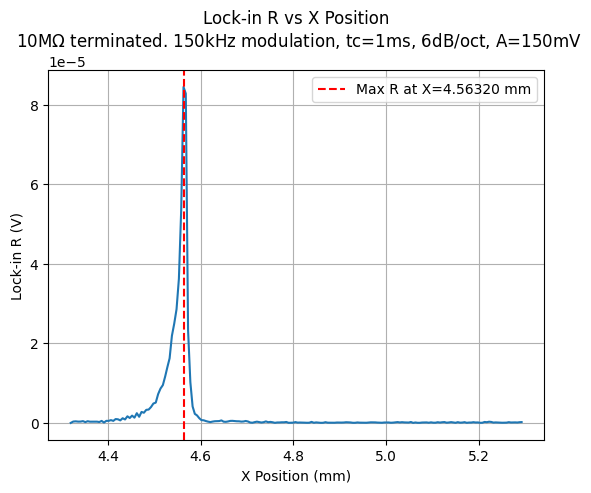

In [93]:
plt.plot(x, r)
plt.xlabel("X Position (mm)")
plt.ylabel("Lock-in R (V)")
plt.title("Lock-in R vs X Position\n 10M$\Omega$ terminated. 150kHz modulation, tc=1ms, 6dB/oct, A=150mV ")
plt.axvline(x[np.argmax(r)], color='r', linestyle='--', label=f'Max R at X={x[np.argmax(r)]:.5f} mm')
plt.grid()
plt.legend()

{'id': '43120', 'jsonrpc': '2.0', 'result': True}

In [99]:
x0, x, r = refocus(1, nsteps=20, stepsize=5, lockin_time_constant=1e-3)

In [101]:
x0

np.float64(4.566945528810066)

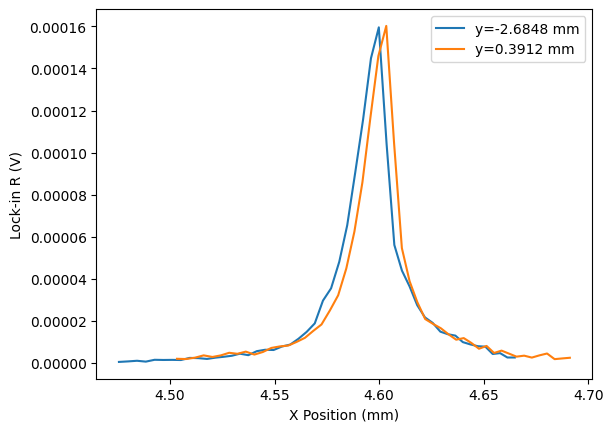

In [4]:
xyz.goPosition(1, 4.5669)
# xyz.wait_closed_loop_done()
xyz.goPosition(2, -1.22)
# xyz.wait_closed_loop_done()

scanSpan = 600 # steps
scanSteps = 20 # number of steps per movement

xyz.goStepsReverse(2, steps=scanSteps*int(scanSpan/2))
# xyz.wait_open_loop_done()

y01 = xyz.getPosition(2)

x01, x1, r1 = refocus(1, nsteps=50, stepsize=15, lockin_time_constant=1e-3)
xyz.goPosition(1, x01)
# xyz.wait_closed_loop_done()

xyz.goStepsForward(2, steps=scanSteps*scanSpan)
# xyz.wait_open_loop_done()


y02 = xyz.getPosition(2)

x02, x2, r2 = refocus(1, nsteps=50, stepsize=15, lockin_time_constant=1e-3)
xyz.goPosition(1, x02)
# xyz.wait_closed_loop_done()

# import matplotlib.pyplot as plt
plt.plot(x1,r1, label=f'y={y01:.4f} mm')
plt.plot(x2,r2, label=f'y={y02:.4f} mm')
plt.xlabel("X Position (mm)")
plt.ylabel("Lock-in R (V)")
plt.legend()


In [15]:
xyz.goPosition(1, 4.5669)
xyz.wait_closed_loop_done()
xyz.goPosition(2, -1.22)
xyz.wait_closed_loop_done()

scanSpan = 600 # steps
scanSteps = 20 # number of steps per movement

xyz.goStepsReverse(2, steps=scanSteps*int(scanSpan/2))
xyz.wait_open_loop_done()
y01 = xyz.getPosition(2)

In [16]:
y01

-0.0026717665878797196

In [18]:
xyz.goStepsForward(2, steps=5000)
time.sleep(1)
print(xyz.getStatusDriveBusy())   # what does this print?
print(xyz.getStatusPositioning()) # and this?

True
False


In [19]:
print(xyz.getStatusDriveBusy())   # what does this print?
print(xyz.getStatusPositioning()) # and this?

False
False


In [21]:
xyz.goStepsReverse(2, steps=5000)
xyz.wait_open_loop_done()
print(xyz.getPosition(2))

-2.5764309794256475


/var/folders/62/mcqwstd50y96l1tfpcvcwz6w0000gn/T/ipykernel_42520/1848252706.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


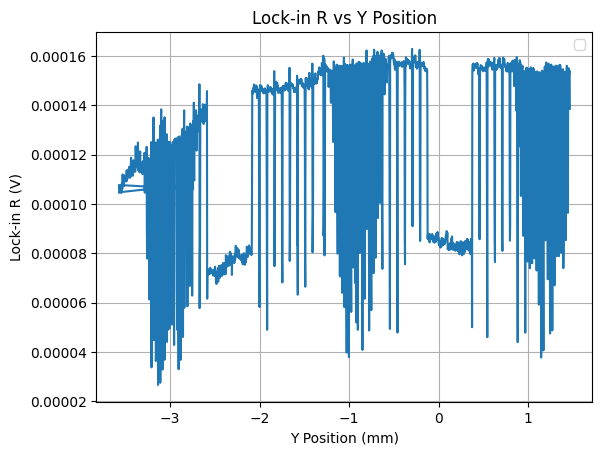

In [5]:
xyz.goPosition(2, -1.15 )
nsteps = 2000
stepsize = 10
y = []
r= []
xyz.goStepsReverse(2, int(nsteps/2)*stepsize)
for i in range(nsteps):
    r.append(lockin.r)
    y.append(xyz.getPosition(2))
    xyz.goStepsForward(2, stepsize)

r = np.array(r)
y = np.array(y)
# np.argmax(r)

plt.plot(y, r)
plt.xlabel("Y Position (mm)")
plt.ylabel("Lock-in R (V)")
plt.title("Lock-in R vs Y Position")
# plt.axvline(y[np.argmax(r)], color='r', linestyle='--', label=f'Max R at Y={y   [np.argmax(r)]:.2f} mm')
plt.grid()
plt.legend()

In [6]:
xyz.goPosition(2, -1.15 )
nsteps = 10000
stepsize = 2
y = []
r= []
xyz.goStepsReverse(2, int(nsteps/2)*stepsize)
for i in range(nsteps):
    r.append(lockin.r)
    y.append(xyz.getPosition(2))
    xyz.goStepsForward(2, stepsize)

r = np.array(r)
y = np.array(y)
# np.argmax(r)

plt.plot(y, r)
plt.xlabel("Y Position (mm)")
plt.ylabel("Lock-in R (V)")
plt.title("Lock-in R vs Y Position")
# plt.axvline(y[np.argmax(r)], color='r', linestyle='--', label=f'Max R at Y={y   [np.argmax(r)]:.2f} mm')
plt.grid()
plt.legend()

KeyboardInterrupt: 

/var/folders/62/mcqwstd50y96l1tfpcvcwz6w0000gn/T/ipykernel_42520/1985044223.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


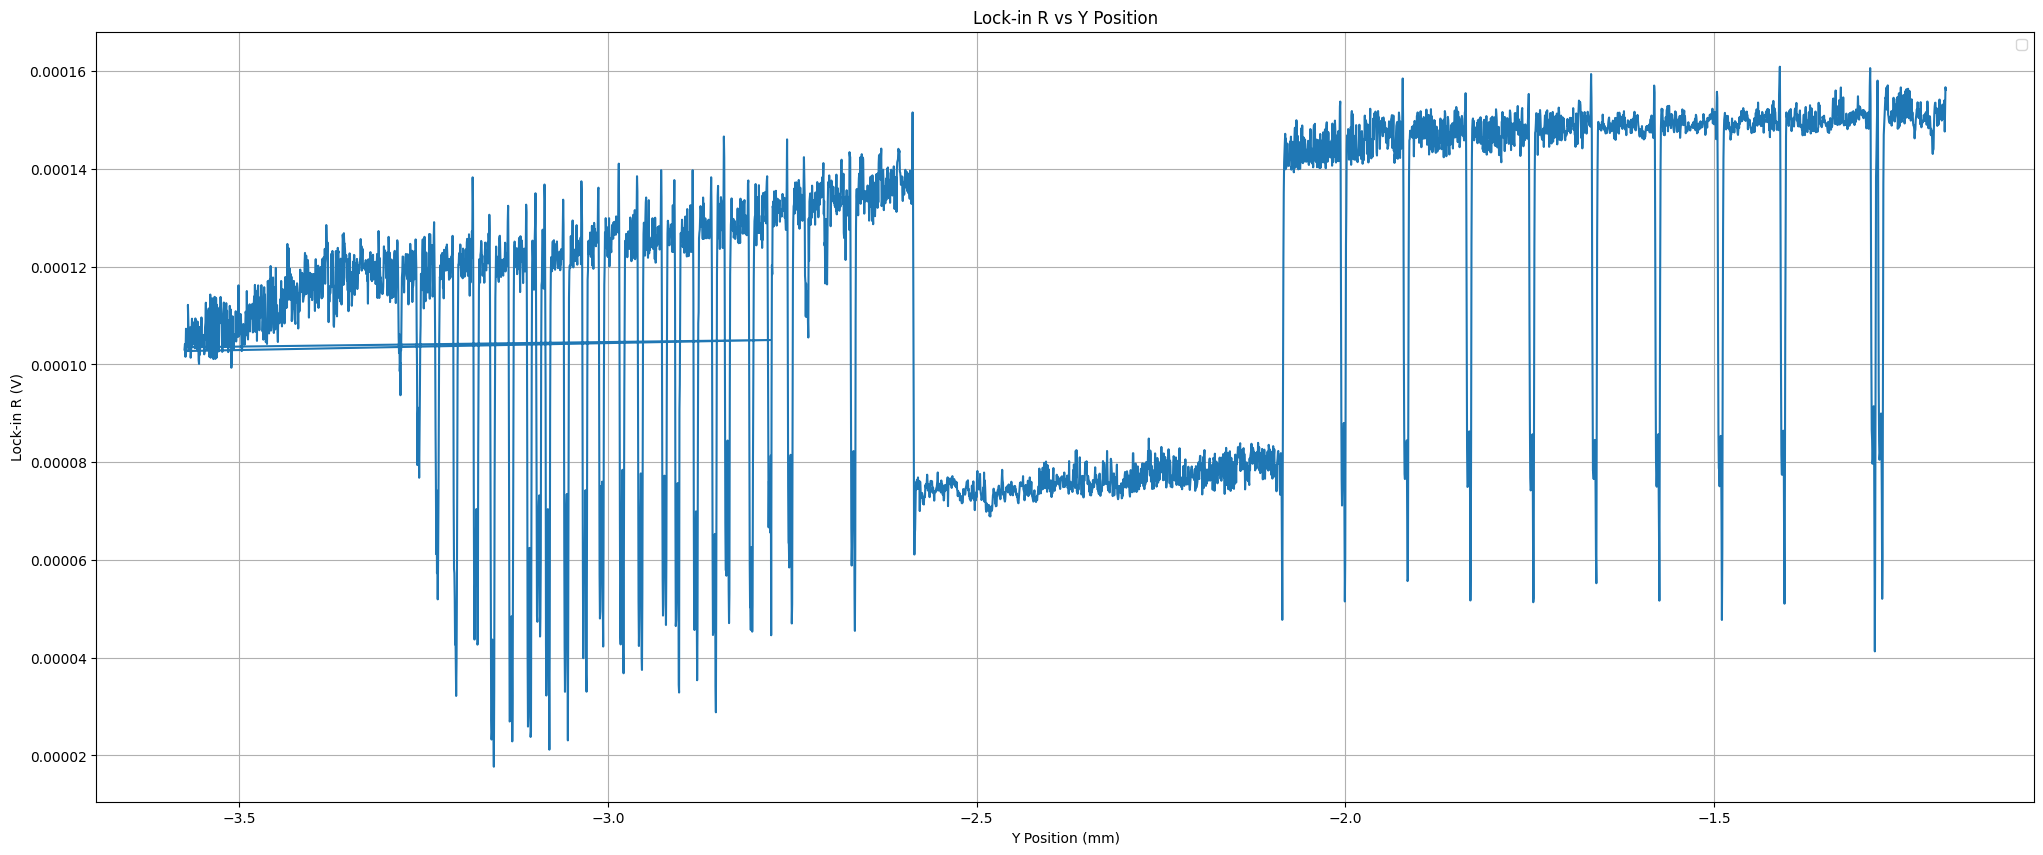

In [12]:
fig, ax = plt.subplots(figsize=(25, 10))
r = np.array(r)
y = np.array(y)
# np.argmax(r)

ax.plot(y, r)
ax.set_xlabel("Y Position (mm)")
ax.set_ylabel("Lock-in R (V)")
ax.set_title("Lock-in R vs Y Position")
# ax.axvline(y[np.argmax(r)], color='r', linestyle='--', label=f'Max R at Y={y   [np.argmax(r)]:.2f} mm')
ax.grid()
plt.legend()

In [13]:
r.size

4707

ValueError: x and y must have same first dimension, but have shapes (1500,) and (1000,)

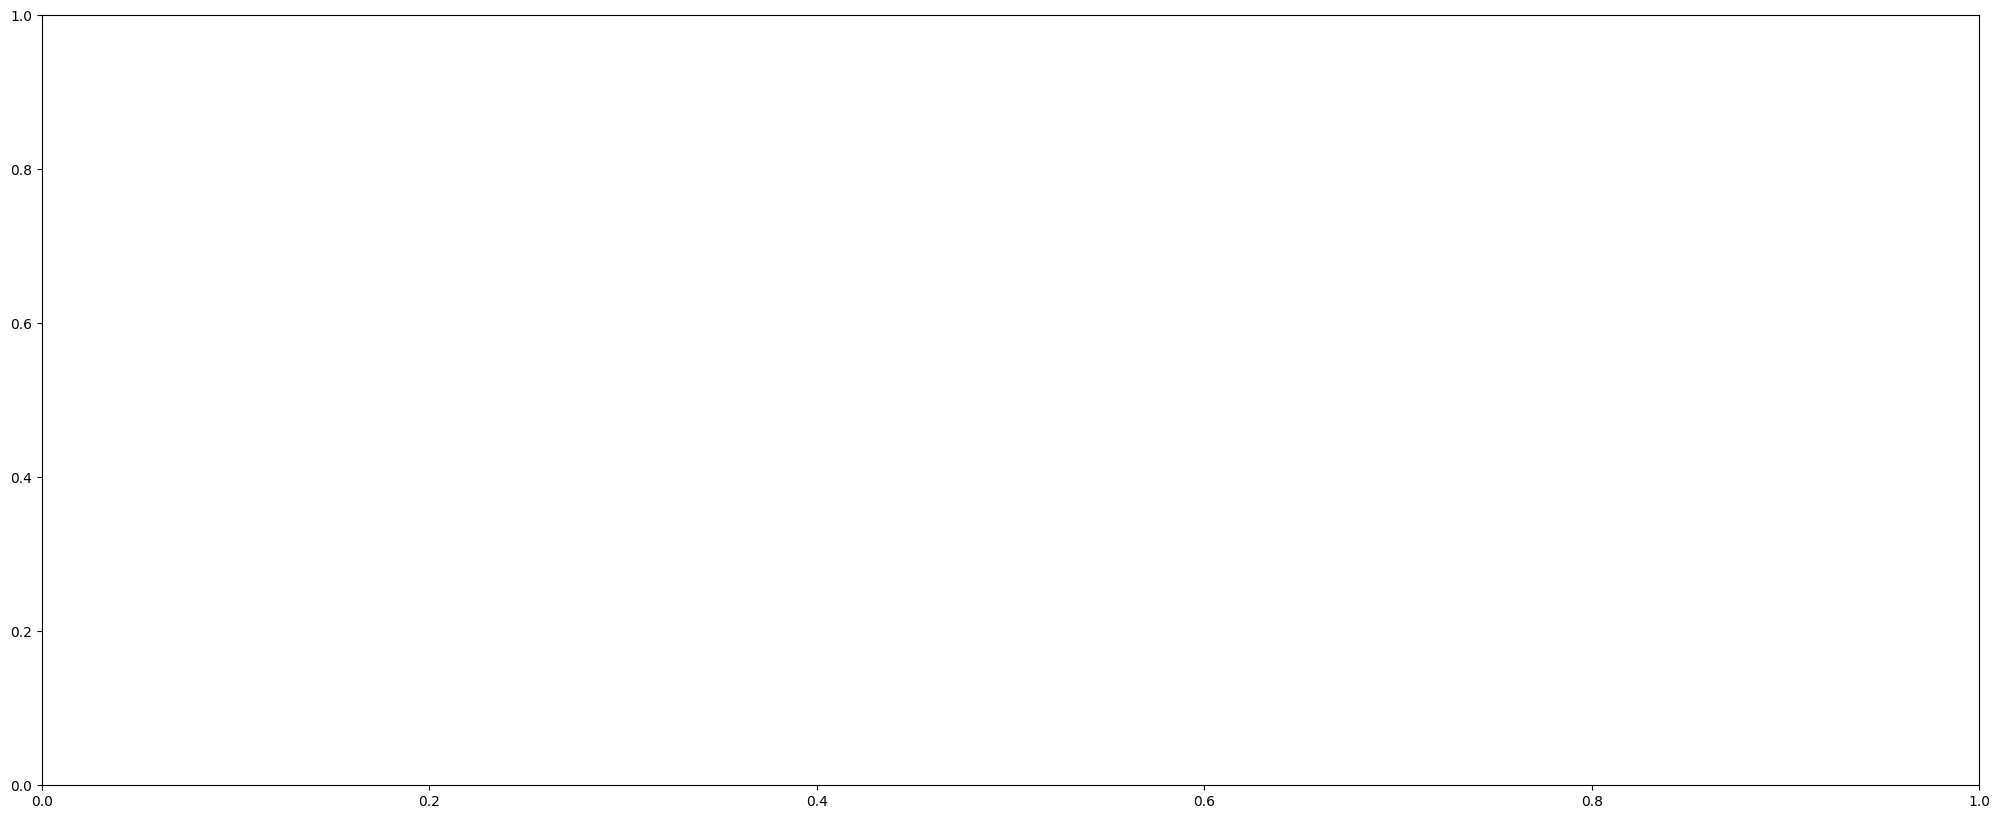

In [16]:
fig, ax = plt.subplots(figsize=(25, 10))
r = np.array(r[500:2000])
y = np.array(y[500:2000])
# np.argmax(r)

ax.plot(y, r)
ax.set_xlabel("Y Position (mm)")
ax.set_ylabel("Lock-in R (V)")
ax.set_title("Lock-in R vs Y Position")
# ax.axvline(y[np.argmax(r)], color='r', linestyle='--', label=f'Max R at Y={y   [np.argmax(r)]:.2f} mm')
ax.grid()
plt.legend()

In [19]:
np.mean(np.diff(y))*1e3

np.float64(0.4972461247031521)

In [ ]:
#100x50um


In [15]:
n_z = 50
n_y = 100
stepsize = 5 #~1um

xyz.goPosition(2, -1.15 )
xyz.goPosition(1, 4.592440)
xyz.goPosition(3, -3.235)

xyz.goStepsReverse(2, steps=stepsize*int(n_y/2))
xyz.goStepsReverse(3, steps=stepsize*int(n_z/2))

r = np.zeros((n_y, n_z))
y = np.zeros((n_y, n_z))
z = np.zeros((n_y, n_z))

for i in range(n_y):
    xyz.goStepsForward(2, steps=stepsize)
    for j in range(n_z):
        xyz.goStepsForward(3, steps=stepsize)
        r[i,j] = lockin.r
        y[i,j] = xyz.getPosition(2)
        z[i,j] = xyz.getPosition(3)
        
    xyz.goStepsReverse(3, steps=stepsize*n_z)  # return to starting Z position before next Y step

# Save to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"scan_yz_{timestamp}.csv"

df = pd.DataFrame({
    'y_mm': y.flatten(),
    'z_mm': z.flatten(),
    'r':    r.flatten()
})

df.to_csv(filename, index=False)
print(f">> Saved {len(df)} points to {filename}")

KeyboardInterrupt: 

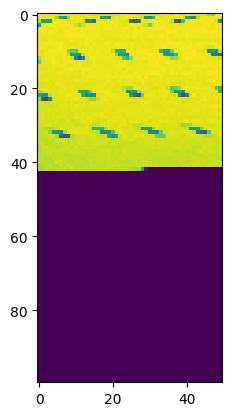

In [26]:
plt.imshow(r)

In [30]:
np.mean(np.diff(y))

np.float64(0.000234629766639019)

In [31]:
np.mean(np.diff(z))

np.float64(0.00042754116339358017)

In [ ]:
yy = np.linspace(y[0], np.mean(np.diff(y))*n_y, n_y)
zz = np.linspace(z[0], np.mean(np.diff(z))*n_z, n_z)

In [33]:
YY, ZZ = np.meshgrid(yy, zz)

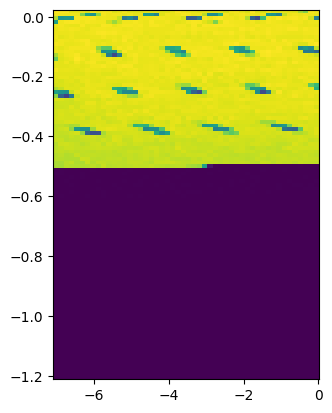

In [49]:
plt.imshow(r, extent=[z.min(), np.mean(np.diff(z))*n_z, y.min(), np.mean(np.diff(y))*n_y], aspect= 8)

In [38]:
X.shape

NameError: name 'X' is not defined

In [36]:
zz.shape

(50, 50)